In [1]:
import os
import glob
import pandas as pd
import numpy as np
import anndata as ad
from scipy import sparse
from sklearn.preprocessing import OneHotEncoder

In [2]:

def build_anndata_from_folder(folder):
    abundance_files = sorted(
        glob.glob(os.path.join(folder, "*_relative_abundance_abundance.csv"))
    )
    
    # EXCLUDE_META_COLS = {
    #     "study_name",
    #     "subject_id",
    #     "pmid",
    #     "curator",
    #     "NCBI_accession",
    # }

    adatas = []

    for abund_path in abundance_files:
        prefix = abund_path.replace("_relative_abundance_abundance.csv", "")
        meta_path = prefix + "_relative_abundance_metadata.csv"

        # if not os.path.exists(meta_path):
        #     raise FileNotFoundError(f"Missing metadata file for {abund_path}")

        # ---------- Load abundance ----------
        abund = pd.read_csv(abund_path, index_col=0)
        abund.index.name = "taxa"

        # transpose: samples x taxa
        X = abund.T
        X = X.astype(np.float32)

        # ---------- Load metadata ----------
        meta = pd.read_csv(meta_path, index_col=0)

        # ensure alignment
        meta = meta.loc[X.index]

        # ---------- Build obs_names ----------
        if "study_name" not in meta.columns:
            raise ValueError(f"'study_name' missing in {meta_path}")

        if "NCBI_accession" in meta.columns:
            sample_id = meta["NCBI_accession"].astype(str)
        else:
            study = meta["study_name"].iloc[0]
            print(
                f"[WARN] NCBI_accession missing for study '{study}'. "
                "Using metadata row index as sample_id."
            )
            sample_id = meta.index.astype(str)

        obs_names = meta["study_name"].astype(str) + "_" + sample_id

        X.index = obs_names
        meta.index = obs_names
        
        obs = meta["study_name"].to_frame()

        # ---------- Build AnnData ----------
        adata = ad.AnnData(
            X=sparse.csr_matrix(X.values),
            obs=obs,
            var=pd.DataFrame(index=abund.index)
        )

        adatas.append(adata)
    
    return adatas

def merge_anndata(adatas):
    # ---- Concatenate all AnnDatas ----
    if len(adatas) == 1:
        adata_merged = adatas[0]
    else:
        print(adatas[0])
        adata_merged = ad.concat(
            adatas,
            axis=0,
            join="outer",
            merge="unique",
            index_unique=None,
            fill_value=0,
        )

    # # ---- Save metadata CSV ----
    # output_csv = os.path.join(folder, "all_metadata_flat.csv")
    # meta_df.to_csv(output_csv, index=False)

    print(f"[INFO] Merged AnnData shape = {adata_merged.shape}")

    return adata_merged


In [3]:
adatas = build_anndata_from_folder("/home/kchen/microbiome/gut_microbiome_GPT/datasets/curated_csv/")
adata_merged = merge_anndata(adatas)

[WARN] NCBI_accession missing for study 'HMP_2019_t2d'. Using metadata row index as sample_id.
[WARN] NCBI_accession missing for study 'LifeLinesDeep_2016'. Using metadata row index as sample_id.
[WARN] NCBI_accession missing for study 'TettAJ_2016'. Using metadata row index as sample_id.
[WARN] NCBI_accession missing for study 'ThomasAM_2018a'. Using metadata row index as sample_id.
[WARN] NCBI_accession missing for study 'ThomasAM_2018b'. Using metadata row index as sample_id.
[WARN] NCBI_accession missing for study 'ThomasAM_2019_c'. Using metadata row index as sample_id.
[WARN] NCBI_accession missing for study 'VilaAV_2018'. Using metadata row index as sample_id.


/home/kchen/miniconda3/envs/hmbGPT/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


[WARN] NCBI_accession missing for study 'HMP_2019_ibdmdb'. Using metadata row index as sample_id.


/home/kchen/miniconda3/envs/hmbGPT/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/kchen/miniconda3/envs/hmbGPT/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


[WARN] NCBI_accession missing for study 'YachidaS_2019'. Using metadata row index as sample_id.
[WARN] NCBI_accession missing for study 'WindTT_2020'. Using metadata row index as sample_id.
AnnData object with n_obs × n_vars = 1098 × 639
    obs: 'study_name'
[INFO] Merged AnnData shape = (22584, 2055)


/home/kchen/miniconda3/envs/hmbGPT/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [4]:
taxa = adata_merged.var_names.to_list()

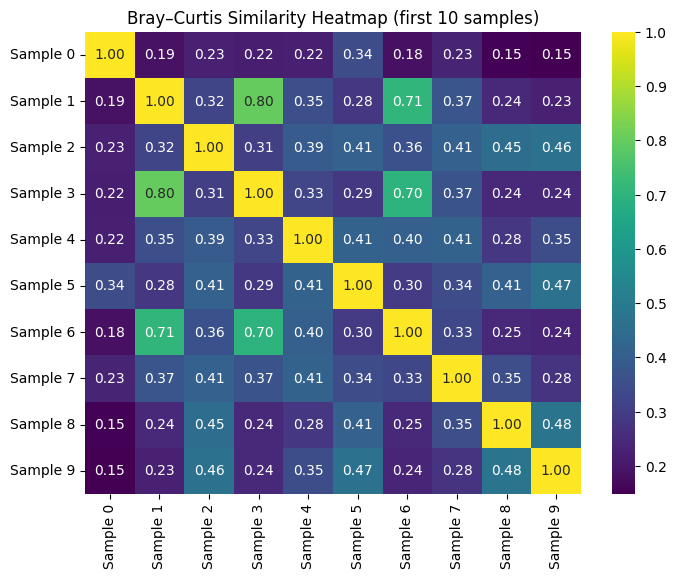

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.spatial.distance import pdist, squareform

# Extract first 10 rows and convert to dense
X_dense = adata_merged.X[:10, :].toarray()

# Compute Bray–Curtis dissimilarity
bc_dissim = squareform(pdist(X_dense, metric="braycurtis"))

# Convert to similarity
bc_similarity = 1.0 - bc_dissim

# Optional: set sample labels
sample_labels = [f"Sample {i}" for i in range(10)]

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    bc_similarity,
    xticklabels=sample_labels,
    yticklabels=sample_labels,
    annot=True,        # show values
    fmt=".2f",
    cmap="viridis"
)
plt.title("Bray–Curtis Similarity Heatmap (first 10 samples)")
plt.show()


In [6]:
save_folder = "/home/kchen/microbiome/gut_microbiome_GPT/datasets/metagenomics/"
adata_merged.write_h5ad(os.path.join(save_folder, "merged_curated.h5ad"))

In [7]:
adata_merged

AnnData object with n_obs × n_vars = 22584 × 2055
    obs: 'study_name'

In [8]:
taxa

['k__Archaea|p__Euryarchaeota|c__Methanobacteria|o__Methanobacteriales|f__Methanobacteriaceae|g__Methanobacterium|s__Methanobacterium_formicicum',
 'k__Archaea|p__Euryarchaeota|c__Methanobacteria|o__Methanobacteriales|f__Methanobacteriaceae|g__Methanobacterium|s__Methanobacterium_sp_MB1',
 'k__Archaea|p__Euryarchaeota|c__Methanobacteria|o__Methanobacteriales|f__Methanobacteriaceae|g__Methanobrevibacter|s__Methanobrevibacter_arboriphilus',
 'k__Archaea|p__Euryarchaeota|c__Methanobacteria|o__Methanobacteriales|f__Methanobacteriaceae|g__Methanobrevibacter|s__Methanobrevibacter_oralis',
 'k__Archaea|p__Euryarchaeota|c__Methanobacteria|o__Methanobacteriales|f__Methanobacteriaceae|g__Methanobrevibacter|s__Methanobrevibacter_ruminantium',
 'k__Archaea|p__Euryarchaeota|c__Methanobacteria|o__Methanobacteriales|f__Methanobacteriaceae|g__Methanobrevibacter|s__Methanobrevibacter_smithii',
 'k__Archaea|p__Euryarchaeota|c__Methanobacteria|o__Methanobacteriales|f__Methanobacteriaceae|g__Methanobrevib